<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS3**: "Análisis de Fourier: FFT, desparramo, interpolación y ventaneo"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

### a) Variación de $k_0$

Para esta práctica voy a generar una señal senoidal  de amplitud $A = \sqrt{2}$ compuesta por una frecuencia $f_0 = k_0 \cdot \frac{f_S}{N} = k_0 \cdot \Delta f$. La frecuencia de muestreo será $ f_s = 500 Hz $ y la cantidad de muestras seran $ N = 500 $.

Voy a ir variando $k_0$ lo que provocará una variacion en la frecuencia de la señal $f_0$. Los valores de $k_0$ serán:
* $ k_0 = \frac{N}{4}$
* $ k_0 = \frac{N}{4} + 0.25$ 
* $ k_0 = \frac{N}{4} + 0.5$

Estudio la densidad espectral de potencia para cada caso.

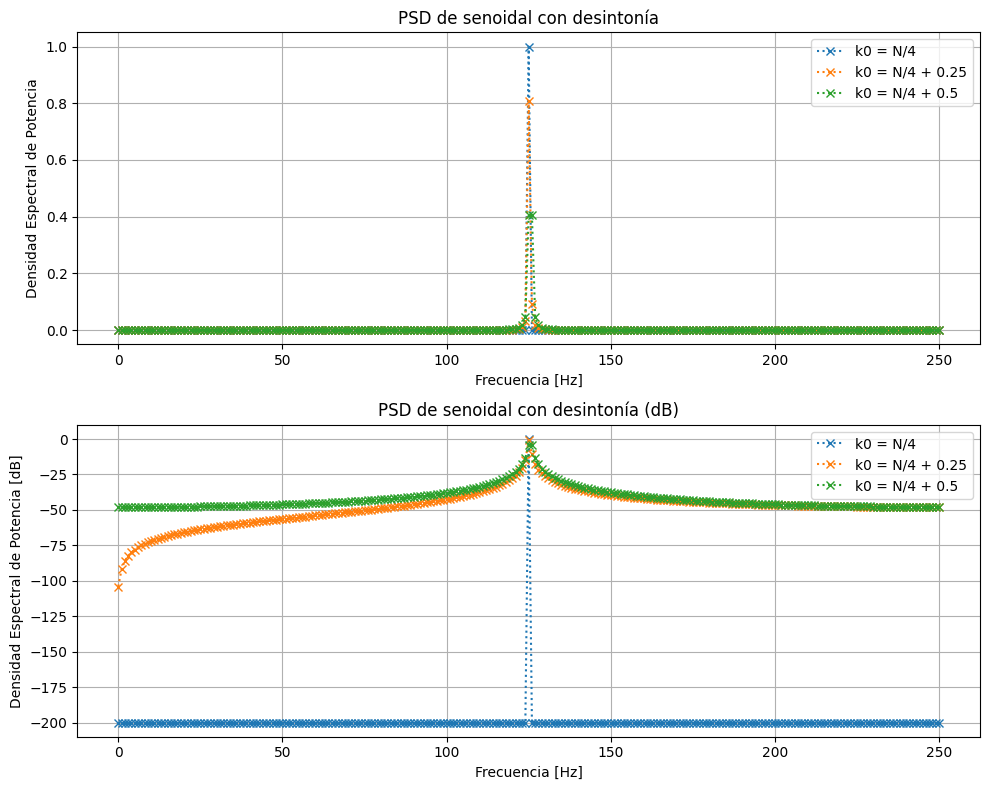

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def funcion_sen(vmax, dc, ff, ph, nn, fs):
    tt = np.arange(nn) / fs
    s = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, s

def calcular_psd_dB(señal, fs):
    N = len(señal)
    S = np.fft.fft(señal) / N
    freqs = np.fft.fftfreq(N, d=1/fs)[:N//2] #genero un vector de frecuencias, le paso la cantidad de muestras y el periodo de meustreo
    psd = (2 / fs) * (np.abs(S[:N//2])**2) * N
    psd_dB = 10 * np.log10(psd + 1e-20)
    return freqs, psd_dB

#Parametros
vmax = np.sqrt(2)
dc = 0
ph = 0
nn = 500 
fs = nn
df = fs/nn

#Definimos las frecuencias

f1 = (nn/4) * df
f2 = (nn/4 + 0.25) * df
f3 = (nn/4 + 0.5) * df


tt1, x1 = funcion_sen(vmax, dc, f1, ph, nn, fs)
tt2, x2 = funcion_sen(vmax, dc, f2, ph, nn, fs)
tt3, x3 = funcion_sen(vmax, dc, f3, ph, nn, fs)
 

freqs1, psd_s1   = calcular_psd_dB(x1, fs)
freqs2, psd_s2   = calcular_psd_dB(x2, fs)
freqs3, psd_s3   = calcular_psd_dB(x3, fs)

# DFT y PSD

XX1 = np.fft.fft(x1)
XX2 = np.fft.fft(x2)
XX3 = np.fft.fft(x3)

PSD1 = (np.abs(XX1)/nn)**2 #Me da la densidad de potencia
PSD2 = (np.abs(XX2)/nn)**2
PSD3 = (np.abs(XX3)/nn)**2

frec = np.arange(nn) * df #Genera el eje de frecuencias de 0 a fs

frec_half = frec[:nn//2 + 1] # me quedo con la mitad

# PSD unilateral

PSD1_uni = PSD1[:nn//2 + 1].copy() #Recorta la mitad positiva del espectro y hace una copia para no modificar el array original
PSD1_uni*= 2 #duplica los valores porque al quedarte con la mitad, perdés la energía que estaba en las frecuencias negativas — multiplicar por 2 la conserva

PSD2_uni = PSD2[:nn//2 + 1].copy()
PSD2_uni *= 2


PSD3_uni = PSD3[:nn//2 + 1].copy()
PSD3_uni *= 2

# PSD en Db

PSD1_uni_db = 10 * np.log10(PSD1_uni + 1e-20)


PSD2_uni_db = 10 * np.log10(PSD2_uni + 1e-20)


PSD3_uni_db = 10 * np.log10(PSD3_uni + 1e-20)

# %% a) Graficar las PSD

#Graficos de la densidad de potencia unilateral
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Subplot 1: lineal ---
ax1.plot(frec_half, PSD1_uni, ':x', label="k0 = N/4")
ax1.plot(frec_half, PSD2_uni, ':x', label="k0 = N/4 + 0.25")
ax1.plot(frec_half, PSD3_uni, ':x', label="k0 = N/4 + 0.5")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad Espectral de Potencia")
ax1.set_title("PSD de senoidal con desintonía")
ax1.legend()
ax1.grid(True)

# --- Subplot 2: dB ---
ax2.plot(frec_half, PSD1_uni_db, ':x', label="k0 = N/4")
ax2.plot(frec_half, PSD2_uni_db, ':x', label="k0 = N/4 + 0.25")
ax2.plot(frec_half, PSD3_uni_db, ':x', label="k0 = N/4 + 0.5")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad Espectral de Potencia [dB]")
ax2.set_title("PSD de senoidal con desintonía (dB)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Se observa que cuando $k_0 = \frac{N}{4}$ (entero), toda la energía se concentra en un único bin de la DFT, ya que la frecuencia de la senoidal coincide exactamente con una frecuencia de la grilla. En los casos $k_0 = \frac{N}{4} + \frac{1}{4}$ y $k_0 = \frac{N}{4} + \frac{1}{2}$, la frecuencia cae entre dos bins, lo que produce el fenómeno de desparramo espectral, donde la energía se distribuye entre múltiples bins vecinos. Esto se evidencia en el gráfico de la densidad espectral, donde el pico máximo es menor que en el caso ideal de $k_0 = N/4$, y se aprecia con mayor claridad en la escala logarítmica (dB), donde se observa que los bins adyacentes adquieren niveles de energía no despreciables.

### a) Verificación de Parseval

Por identidad de Parseval sabameos que la potencia en el dominio del tiempo debe ser la misma potencia que en el dominio de la frecuencia, es decir, se debe cumplir:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

Calculo y verifico la potencia para cada dominio en cada caso estudiado de $k_0$

In [3]:
potencia_temporal_1 = np.mean(x1**2)
potencia_temporal_2 = np.mean(x2**2)
potencia_temporal_3 = np.mean(x3**2)


potencia_freq_1 = np.sum(PSD1_uni) 
potencia_freq_2 = np.sum(PSD2_uni) 
potencia_freq_3 = np.sum(PSD3_uni) 

print("=== Verificación de Parseval ===")
print(f"x1 | Temporal: {potencia_temporal_1:.4f} | Frecuencial: {potencia_freq_1:.4f}")
print(f"x2 | Temporal: {potencia_temporal_2:.4f} | Frecuencial: {potencia_freq_2:.4f}")
print(f"x3 | Temporal: {potencia_temporal_3:.4f} | Frecuencial: {potencia_freq_3:.4f}")

=== Verificación de Parseval ===
x1 | Temporal: 1.0000 | Frecuencial: 1.0000
x2 | Temporal: 0.9980 | Frecuencial: 0.9980
x3 | Temporal: 1.0000 | Frecuencial: 1.0000


Vemos que se verifica la identidad de Parseval donde las potencias son iguales para cada caso en ambos dominios.

Observamos que los espectros para cada $k_0$ es distinto con respecto al otro. Esto se debe al desparramos espectral, la energia en frecuencia no cae en un bin entero sino que cae entre dos bins, lo que provoca que la energia se distribuya a los bins vecinos.

### c) Zero padding

Sabemos que la frecuencia de la señal esta dada como  $f_0 = k_0 \cdot \frac{f_S}{N} = k_0 \cdot \Delta f$. Si nosotros agregamos $N_z$ valores de ceros a nuestra cantidad de muestras estariamos agranando el numero de muestras y como consecuencia se estaría achicando la resolución espectral.